# LumaStyle Customer Lifecycle & Profitability Analytics
## Exploratory Data Analysis (EDA) & Customer Segmentation (RFM / K-Means)

This notebook contains a standardized template for analyzing customer behavior, transactions, returns, and marketing spend for **LumaStyle**.

### Objectives:
1. **Exploratory Data Analysis**: Understand customer signups, channel performance, product categories, and returns.
2. **RFM Feature Engineering**: Extract **Recency**, **Frequency**, and **Monetary** values for each customer.
3. **K-Means Clustering**: Segment customers into distinct profiles for targeted marketing and customer retention campaigns.
4. **Profitability Analysis**: Compare customer segments by acquisition channel, CAC, and overall net lifetime value (CLV).

### 1. Environment Setup & Data Ingestion

In [1]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Add parent directory to path to import the src modules
sys.path.append(os.path.abspath(os.path.join('..')))

from src.ingestion import load_csv_data
from src.transformation import transform_customer_metrics, transform_marketing_channels

# Visualization Styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

print("Libraries loaded successfully.")

Libraries loaded successfully.


### 2. Load Raw and Transformed Data

In [2]:
# Load raw tables for EDA
df_customers = load_csv_data("customers")
df_transactions = load_csv_data("transactions")
df_returns = load_csv_data("product_returns")
df_marketing = load_csv_data("marketing_spend")

# Load customer-level transformed metrics table
df_customer_metrics = pd.read_csv("../data/customer_metrics.csv")
df_channel_perf = pd.read_csv("../data/channel_performance.csv")

print(f"Loaded {df_customer_metrics.shape[0]} customer records for analysis.")

2026-07-25 12:04:34,583 - INFO - Ingesting customers from D:\PROGRAMMING\PROJECTS\E COmmerce\data\customers.csv...


2026-07-25 12:04:34,630 - INFO - Successfully ingested customers - Rows: 1500, Columns: 9


2026-07-25 12:04:34,632 - INFO - Ingesting transactions from D:\PROGRAMMING\PROJECTS\E COmmerce\data\transactions.csv...


2026-07-25 12:04:34,685 - INFO - Successfully ingested transactions - Rows: 6669, Columns: 9


2026-07-25 12:04:34,686 - INFO - Ingesting product_returns from D:\PROGRAMMING\PROJECTS\E COmmerce\data\product_returns.csv...


2026-07-25 12:04:34,693 - INFO - Successfully ingested product_returns - Rows: 473, Columns: 5


2026-07-25 12:04:34,694 - INFO - Ingesting marketing_spend from D:\PROGRAMMING\PROJECTS\E COmmerce\data\marketing_spend.csv...


2026-07-25 12:04:34,728 - INFO - Successfully ingested marketing_spend - Rows: 4560, Columns: 8


Loaded 1500 customer records for analysis.


### 3. Exploratory Data Analysis (EDA)
Let's explore customer distributions, acquisition channel signups, and transaction patterns.

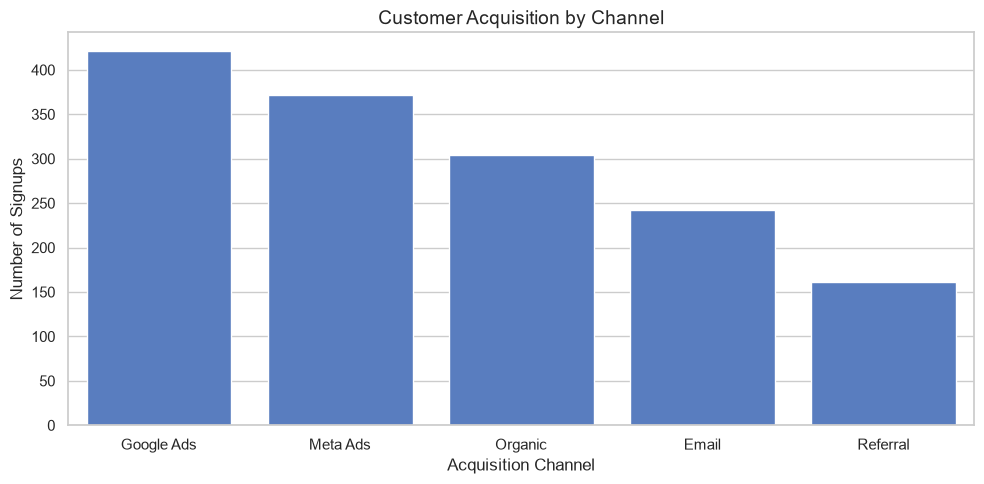

In [3]:
# 3.1 Acquisition Channel Performance
plt.figure(figsize=(10, 5))
sns.countplot(data=df_customers, x='acquisition_channel', order=df_customers['acquisition_channel'].value_counts().index)
plt.title('Customer Acquisition by Channel')
plt.xlabel('Acquisition Channel')
plt.ylabel('Number of Signups')
plt.tight_layout()
plt.show()

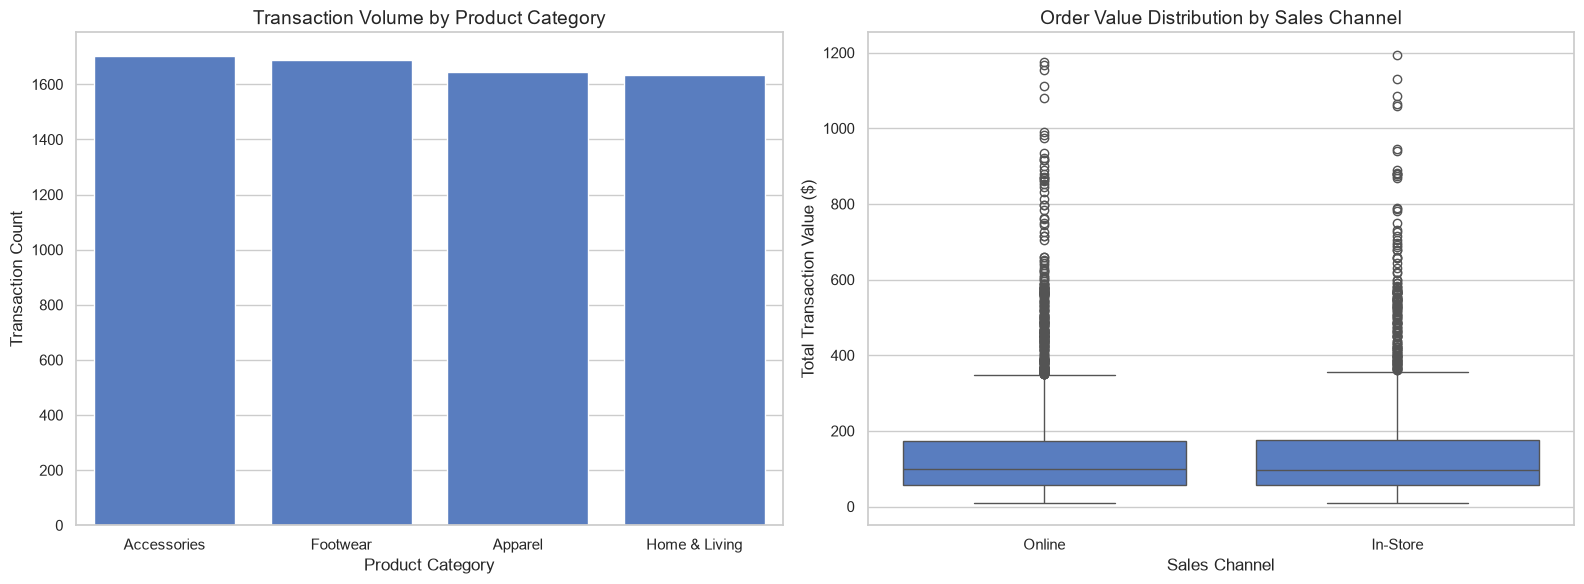

In [4]:
# 3.2 Product Category and Sales Channels
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

sns.countplot(data=df_transactions, x='product_category', ax=ax[0], order=df_transactions['product_category'].value_counts().index)
ax[0].set_title('Transaction Volume by Product Category')
ax[0].set_xlabel('Product Category')
ax[0].set_ylabel('Transaction Count')

sns.boxplot(data=df_transactions, x='sales_channel', y='total_amount', ax=ax[1])
ax[1].set_title('Order Value Distribution by Sales Channel')
ax[1].set_xlabel('Sales Channel')
ax[1].set_ylabel('Total Transaction Value ($)')

plt.tight_layout()
plt.show()

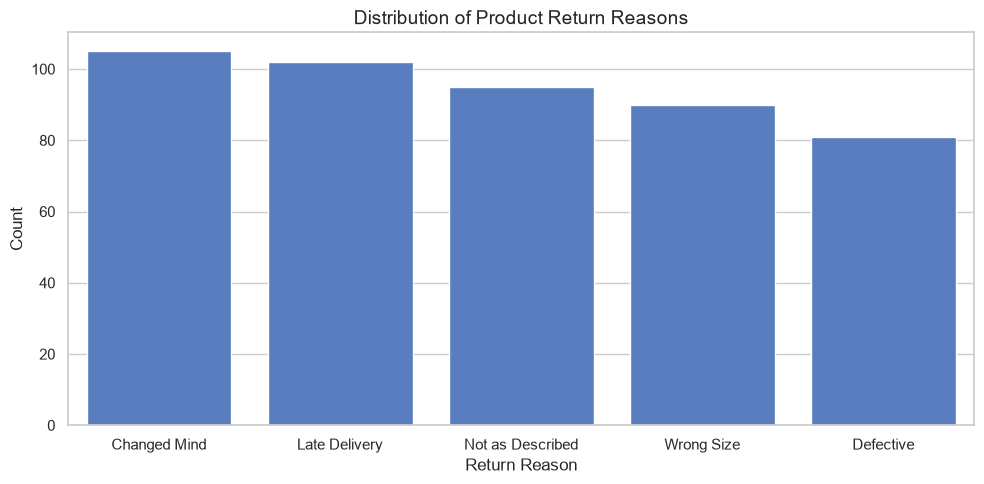

In [5]:
# 3.3 Return Reasons
plt.figure(figsize=(10, 5))
sns.countplot(data=df_returns, x='return_reason', order=df_returns['return_reason'].value_counts().index)
plt.title('Distribution of Product Return Reasons')
plt.xlabel('Return Reason')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### 4. RFM (Recency, Frequency, Monetary) Feature Selection
We extract Recency, Frequency, and Monetary value for each customer from `df_customer_metrics`.

In [6]:
# Keep only transactional customers (frequency > 0)
rfm_data = df_customer_metrics[df_customer_metrics['frequency'] > 0][['customer_id', 'recency', 'frequency', 'net_monetary']].copy()
rfm_data.rename(columns={'net_monetary': 'monetary'}, inplace=True)
print(f"Analyzing RFM for {rfm_data.shape[0]} active customers.")
print(rfm_data.describe())

Analyzing RFM for 1489 active customers.
           recency    frequency     monetary
count  1489.000000  1489.000000  1489.000000
mean    138.478845     4.478845   569.160275
std     156.173540     4.650383   656.407278
min       1.000000     1.000000     0.000000
25%      27.000000     2.000000   163.950000
50%      79.000000     3.000000   370.910000
75%     192.000000     6.000000   731.720000
max     884.000000    62.000000  8011.790000


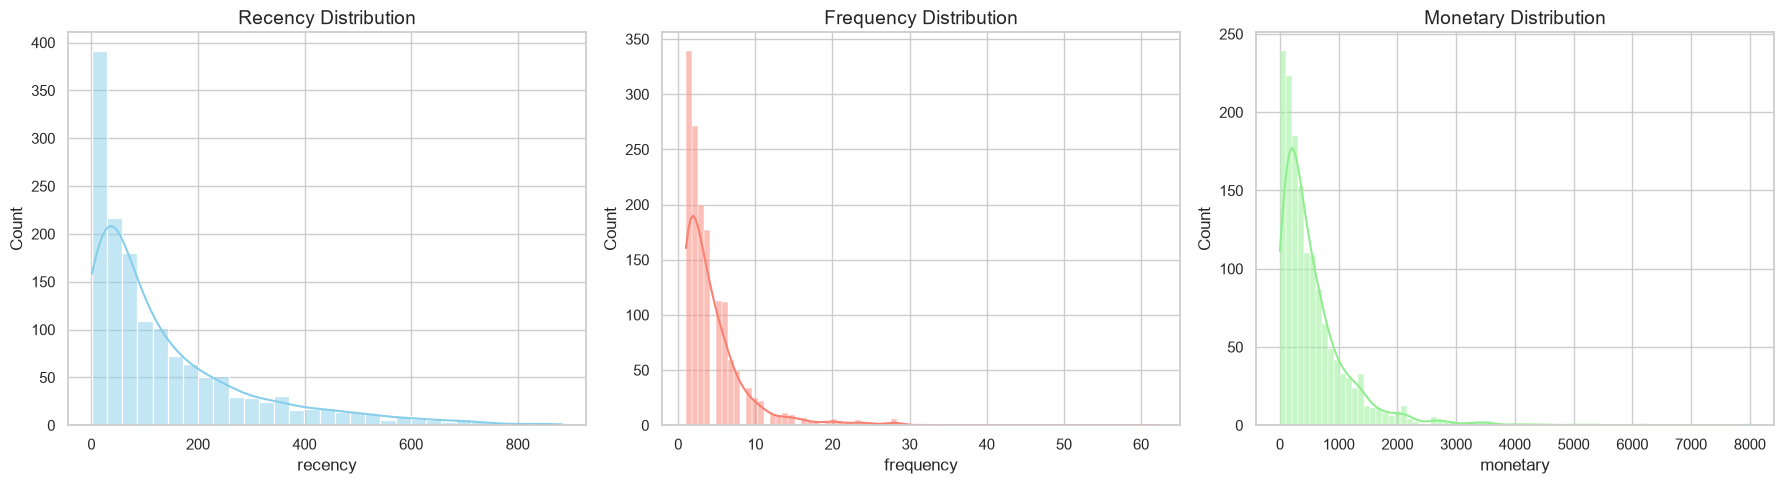

In [7]:
# Plot RFM Distributions
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(rfm_data['recency'], kde=True, ax=ax[0], color='skyblue')
ax[0].set_title('Recency Distribution')

sns.histplot(rfm_data['frequency'], kde=True, ax=ax[1], color='salmon')
ax[1].set_title('Frequency Distribution')

sns.histplot(rfm_data['monetary'], kde=True, ax=ax[2], color='lightgreen')
ax[2].set_title('Monetary Distribution')
plt.tight_layout()
plt.savefig("../outputs/figures/rfm_distributions.png", bbox_inches="tight")
plt.show()


### 5. RFM Preprocessing & Scaling
Since K-Means is sensitive to skewness and feature scales, we log-transform (or use Yeo-Johnson/Box-Cox) to normalize distributions, then apply `StandardScaler`.

In [8]:
# Apply Log transformation to handle skewness (adding small constant to handle non-positive monetary value if any)
rfm_log = rfm_data[['recency', 'frequency', 'monetary']].copy()
rfm_log['monetary'] = np.where(rfm_log['monetary'] <= 0, 1e-5, rfm_log['monetary']) # avoid log(0) or negative monetary values

rfm_log = np.log(rfm_log)

# Standardize features
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)
rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=['recency', 'frequency', 'monetary'])

print("RFM features scaled successfully.")
print(rfm_scaled_df.describe())

RFM features scaled successfully.
            recency     frequency      monetary
count  1.489000e+03  1.489000e+03  1.489000e+03
mean   1.192986e-16  1.407724e-16  2.720009e-16
std    1.000336e+00  1.000336e+00  1.000336e+00
min   -2.930687e+00 -1.358943e+00 -6.793389e+00
25%   -6.236035e-01 -5.288962e-01 -1.778310e-01
50%    1.279234e-01 -4.335017e-02  1.472816e-01
75%    7.495561e-01  7.866962e-01  4.178530e-01
max    1.818428e+00  3.583317e+00  1.370921e+00


### 6. Determine Optimal Number of Clusters
We use the **Elbow Method** (Sum of Squared Errors) and check **Silhouette Scores** to identify the best cluster count.

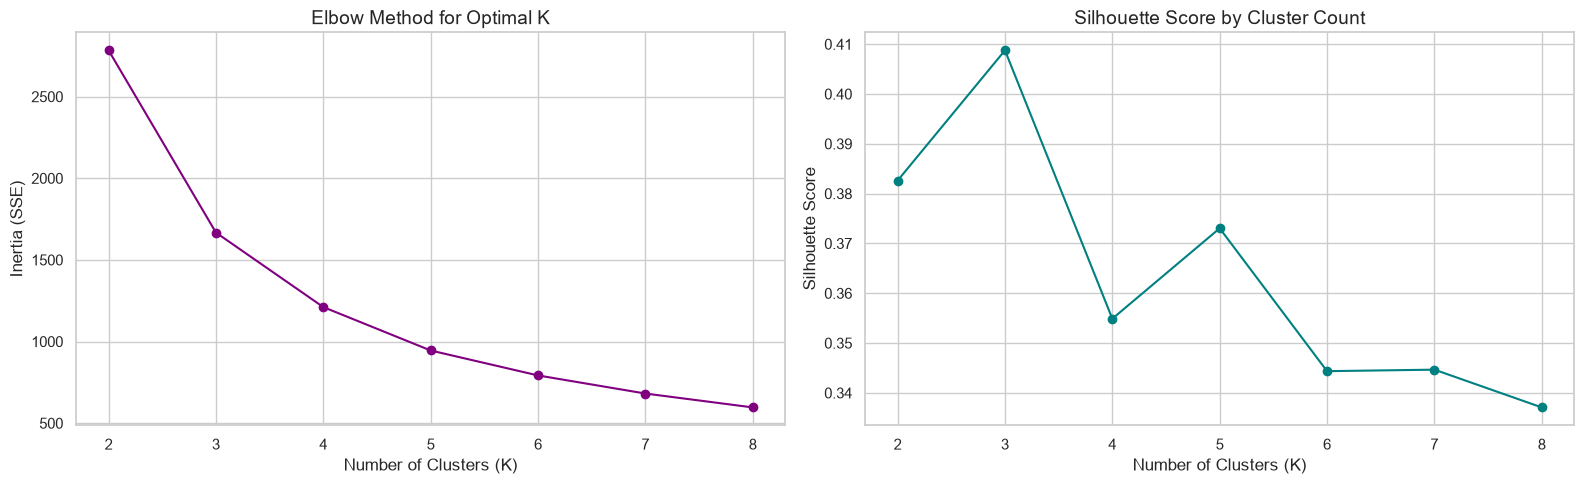

In [9]:
sse = {}
silhouette_avg = {}
cluster_range = range(2, 9)

for k in cluster_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    sse[k] = kmeans.inertia_
    silhouette_avg[k] = silhouette_score(rfm_scaled, kmeans.labels_)

# Plot metrics
fig, ax = plt.subplots(1, 2, figsize=(16, 5))

ax[0].plot(list(sse.keys()), list(sse.values()), marker='o', color='purple')
ax[0].set_title('Elbow Method for Optimal K')
ax[0].set_xlabel('Number of Clusters (K)')
ax[0].set_ylabel('Inertia (SSE)')

ax[1].plot(list(silhouette_avg.keys()), list(silhouette_avg.values()), marker='o', color='teal')
ax[1].set_title('Silhouette Score by Cluster Count')
ax[1].set_xlabel('Number of Clusters (K)')
ax[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.savefig("../outputs/figures/kmeans_optimal_k.png", bbox_inches="tight")
plt.show()


### 7. Fit K-Means Clustering
Select the optimal number of clusters (typically $k=3$ or $k=4$ for RFM segmentation) and profile them.

In [10]:
OPTIMAL_K = 4 # Adjust based on the plots above
kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
kmeans.fit(rfm_scaled)

rfm_data['cluster'] = kmeans.labels_

# Identify clusters dynamically based on their monetary value
cluster_means = rfm_data.groupby('cluster').agg({'recency':'mean', 'frequency':'mean', 'monetary':'mean'}).reset_index()
sorted_by_monetary = cluster_means.sort_values('monetary', ascending=False)['cluster'].tolist()

cluster_map = {
    sorted_by_monetary[0]: 'Champions',
    sorted_by_monetary[1]: 'Loyal Customers',
    sorted_by_monetary[2]: 'High-Risk Churners',
    sorted_by_monetary[3]: 'Value Destroyers'
}

rfm_data['segment'] = rfm_data['cluster'].map(cluster_map)

# Merge segment labels back to df_customer_metrics
df_customer_metrics = pd.merge(df_customer_metrics, rfm_data[['customer_id', 'segment']], on='customer_id', how='left')
df_customer_metrics['segment'] = df_customer_metrics['segment'].fillna('Inactive')

print(f"Assigned segments to {rfm_data.shape[0]} active customers.")
print("\nSegment Profile Means:")
print(rfm_data.groupby('segment').agg({
    'recency': 'mean',
    'frequency': 'mean',
    'monetary': 'mean',
    'customer_id': 'count'
}).rename(columns={'customer_id': 'customer_count'}))


Assigned segments to 1489 active customers.

Segment Profile Means:
                       recency  frequency     monetary  customer_count
segment                                                               
Champions            13.562319   8.797101  1122.955652             345
High-Risk Churners  244.324627   1.451493   182.832425             536
Loyal Customers     110.431271   4.857388   622.099261             582
Value Destroyers    241.807692   1.115385     0.000000              26


### 8. Segment Profiling & Visualizations
Create visualizations to interpret each cluster (e.g. VIP, Recent Shoppers, Slipping/Chruned Customers, Low Value).

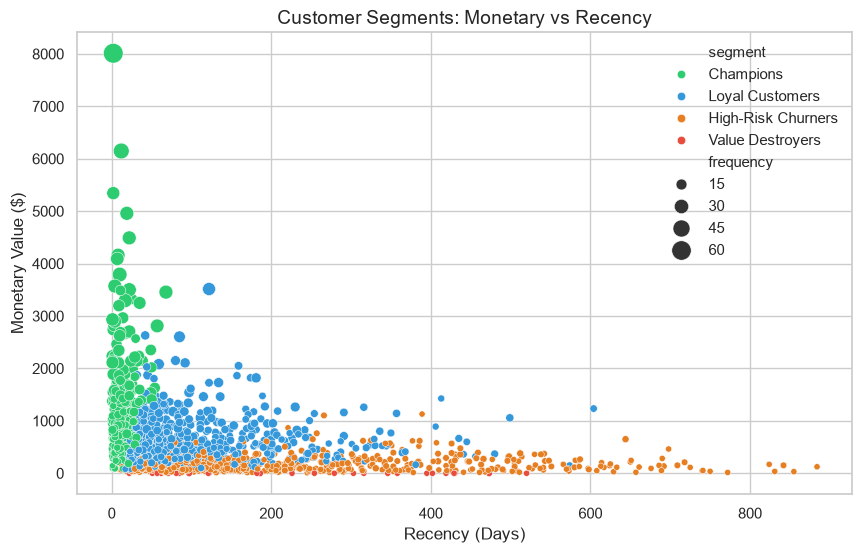

In [11]:
# Custom palette for premium visual look
colors = {
    'Champions': '#2ecc71',
    'Loyal Customers': '#3498db',
    'High-Risk Churners': '#e67e22',
    'Value Destroyers': '#e74c3c'
}

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=rfm_data, 
    x='recency', 
    y='monetary', 
    hue='segment', 
    hue_order=['Champions', 'Loyal Customers', 'High-Risk Churners', 'Value Destroyers'],
    palette=colors, 
    size='frequency', 
    sizes=(20, 200)
)
plt.title('Customer Segments: Monetary vs Recency')
plt.xlabel('Recency (Days)')
plt.ylabel('Monetary Value ($)')
plt.savefig("../outputs/figures/customer_segments_scatter.png", bbox_inches="tight")
plt.show()


### 9. Acquisition Channel ROI and Profitability Analysis
Let's join customer segment profiles back with CAC and marketing channel spend metrics to look at profitability.

In [12]:
# Group Customer Value and Tenure by Acquisition Channel
channel_value = df_customer_metrics.groupby('acquisition_channel').agg(
    customer_count=('customer_id', 'count'),
    avg_frequency=('frequency', 'mean'),
    avg_net_monetary=('net_monetary', 'mean'),
    total_net_value=('net_monetary', 'sum')
).reset_index()

channel_value.rename(columns={'acquisition_channel': 'channel'}, inplace=True)
channel_roi = pd.merge(channel_value, df_channel_perf, on='channel')

# Compute Simple LTV / CAC Ratio
channel_roi['ltv_to_cac'] = (channel_roi['avg_net_monetary'] / channel_roi['cac']).round(2)
channel_roi['net_profitability'] = channel_roi['total_net_value'] - channel_roi['total_spend']

print("Channel Profitability Comparison:")
print(channel_roi[['channel', 'customer_count', 'cac', 'avg_net_monetary', 'ltv_to_cac', 'net_profitability']])

Channel Profitability Comparison:
      channel  customer_count     cac  avg_net_monetary  ltv_to_cac  \
0       Email             242  183.60        524.458306        2.86   
1  Google Ads             421  705.54        541.273159        0.77   
2    Meta Ads             372  675.06        472.243468        0.70   
3     Organic             304    0.00        640.859243         inf   
4    Referral             161    0.00        758.937640         inf   

   net_profitability  
0           82487.06  
1          -69157.31  
2          -75449.52  
3          194821.21  
4          122188.96  


C:\Users\Bikash Bhattacharjee\AppData\Local\Temp\ipykernel_8836\4049196360.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=channel_roi, x='channel', y='ltv_to_cac', palette='magma')


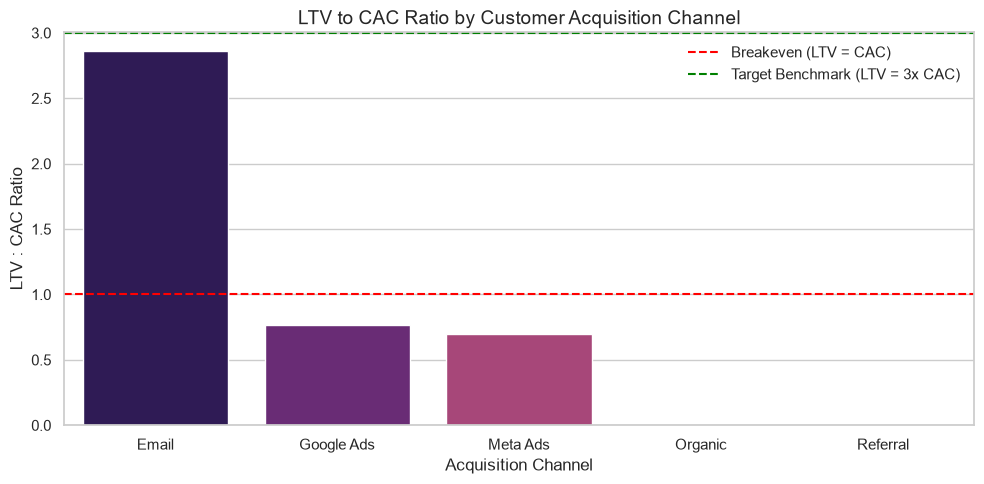

In [13]:
# Visualizing LTV:CAC Ratio by Channel
plt.figure(figsize=(10, 5))
sns.barplot(data=channel_roi, x='channel', y='ltv_to_cac', palette='magma')
plt.axhline(1.0, color='red', linestyle='--', label='Breakeven (LTV = CAC)')
plt.axhline(3.0, color='green', linestyle='--', label='Target Benchmark (LTV = 3x CAC)')
plt.title('LTV to CAC Ratio by Customer Acquisition Channel')
plt.xlabel('Acquisition Channel')
plt.ylabel('LTV : CAC Ratio')
plt.legend()
plt.tight_layout()
plt.savefig("../outputs/figures/ltv_cac_by_channel.png", bbox_inches="tight")
plt.show()


### 10. Segment LTV vs. CAC Analysis & Summary Statistics
We now join our segment definitions back with marketing CAC costs to analyze profitability and ROI per customer segment.

Customer Segment Profitability & ROI Report:
           segment  customer_count     avg_ltv    avg_cac  total_ltv  total_cac  ltv_to_cac
         Champions             345 1122.955652 328.598609  387419.70  113366.52        3.42
High-Risk Churners             536  182.832425 430.982910   97998.18  231006.84        0.42
          Inactive              11    0.000000 423.829091       0.00    4662.12        0.00
   Loyal Customers             582  622.099261 396.756907  362061.77  230912.52        1.57
  Value Destroyers              26    0.000000 486.071538       0.00   12637.86        0.00


C:\Users\Bikash Bhattacharjee\AppData\Local\Temp\ipykernel_8836\4076908743.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


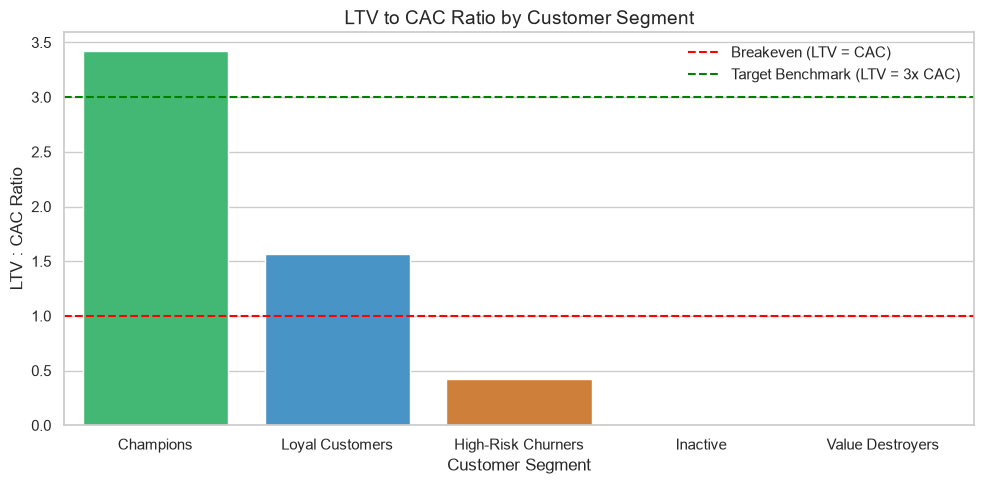

In [14]:
# Merge channel performance to get CAC per customer
df_customer_metrics_analysis = pd.merge(
    df_customer_metrics, 
    df_channel_perf[['channel', 'cac']], 
    left_on='acquisition_channel', 
    right_on='channel', 
    how='left'
)

segment_summary = df_customer_metrics_analysis.groupby('segment').agg(
    customer_count=('customer_id', 'count'),
    avg_ltv=('net_monetary', 'mean'),
    avg_cac=('cac', 'mean'),
    total_ltv=('net_monetary', 'sum'),
    total_cac=('cac', 'sum')
).reset_index()

segment_summary['ltv_to_cac'] = (segment_summary['avg_ltv'] / segment_summary['avg_cac']).round(2)

print("Customer Segment Profitability & ROI Report:")
print(segment_summary.to_string(index=False))

# Visualizing LTV:CAC Ratio by Segment
plt.figure(figsize=(10, 5))
segment_colors = {
    'Champions': '#2ecc71',
    'Loyal Customers': '#3498db',
    'High-Risk Churners': '#e67e22',
    'Inactive': '#7f8c8d',
    'Value Destroyers': '#e74c3c'
}
sns.barplot(
    data=segment_summary, 
    x='segment', 
    y='ltv_to_cac', 
    palette=segment_colors,
    order=['Champions', 'Loyal Customers', 'High-Risk Churners', 'Inactive', 'Value Destroyers']
)
plt.axhline(1.0, color='red', linestyle='--', label='Breakeven (LTV = CAC)')
plt.axhline(3.0, color='green', linestyle='--', label='Target Benchmark (LTV = 3x CAC)')
plt.title('LTV to CAC Ratio by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('LTV : CAC Ratio')
plt.legend()
plt.tight_layout()
plt.savefig("../outputs/figures/ltv_cac_by_segment.png", bbox_inches="tight")
plt.show()
